# Exponential Family Factor Analysis

## Real-World Scenario: Tumor Mutation Profiles as Binary Data

Cancer genomics produces a **binary mutation matrix** — one row per patient, one column per gene, with $x_{nd} \in \{0, 1\}$ encoding whether gene $d$ carries a non-silent mutation in tumor $n$. This is *not* Gaussian: the marginal of $x_{nd}$ is a Bernoulli with a low base rate (typically 1–20% per gene), and standard PCA / factor analysis incorrectly model it as a real-valued feature.

Yet biology screams *latent structure*: mutations co-occur because tumors disable **shared pathways** — DNA repair (BRCA1/BRCA2/TP53/ATM), PI3K/AKT (PIK3CA/PTEN/AKT1), RAS/RAF (KRAS/BRAF/NRAS), cell cycle (CDKN2A/RB1/MYC). A handful of latent pathway-activity factors $\mathbf{z}_n \in \mathbb{R}^L$ should explain whether each patient's mutations are likely.

**Exponential family factor analysis** (PML §20.2.7) generalises FA / PPCA to non-Gaussian likelihoods by letting the **natural parameters** of the data distribution be a low-rank linear function of the latents:

$$\boldsymbol{\Theta} = \mathbf{Z}\mathbf{W}^\top \quad\text{with}\quad p(\mathbf{x}_n \mid \mathbf{z}_n) = \exp\!\big(\mathcal{T}(\mathbf{x}_n)^\top \boldsymbol{\theta}_n + h(\mathbf{x}_n) - g(\boldsymbol{\theta}_n)\big)$$

We work through:

1. **Why Gaussian PCA fails on binary mutation data**
2. The **exponential family FA** generative model (Eq. 20.73)
3. **Binary PCA** with Bernoulli likelihood (§20.2.7.1)
4. Fitting via **coordinate ascent / variational EM** (CDS02 algorithm)
5. Visualising the recovered **latent pathway space**
6. **Categorical PCA** for genotypes (§20.2.7.2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
from scipy.special import expit as sigmoid, logsumexp

rng = np.random.default_rng(0)
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'

## Key Formulas from PML §20.2.7

**Exponential family FA** (Eq. 20.73). The natural-parameter matrix is low-rank, $\boldsymbol{\Theta} = \mathbf{Z}\mathbf{W}^\top$ with $\mathbf{Z} \in \mathbb{R}^{N\times L}$, $\mathbf{W} \in \mathbb{R}^{D\times L}$, and

$$p(\mathbf{x}_n \mid \mathbf{z}_n) = \exp\!\big(\mathcal{T}(\mathbf{x}_n)^\top \boldsymbol{\theta}_n + h(\mathbf{x}_n) - g(\boldsymbol{\theta}_n)\big), \qquad \boldsymbol{\theta}_n = \mathbf{W}\mathbf{z}_n + \mathbf{b}$$

**Binary PCA** (Eq. 20.74). With Bernoulli outputs,

$$p(\mathbf{x}_n \mid \mathbf{z}_n) = \prod_{d=1}^{D} \mathrm{Ber}\!\big(x_{nd} \,\big|\, \sigma(\mathbf{w}_d^\top \mathbf{z}_n + b_d)\big)$$

**Categorical PCA / CatPCA** (Eq. 20.76). With one-hot categorical outputs,

$$p(\mathbf{x}_n \mid \mathbf{z}_n) = \prod_{d=1}^{D} \mathrm{Cat}\!\big(x_{nd} \,\big|\, \mathrm{softmax}(\mathbf{W}_d \mathbf{z}_n + \mathbf{b}_d)\big)$$

**Why exact MLE is hard.** The likelihood

$$\log p(\mathbf{x}_n \mid \mathbf{W}) = \log \!\int p(\mathbf{x}_n \mid \mathbf{z}_n)\, \mathcal{N}(\mathbf{z}_n \mid \mathbf{0}, \mathbf{I})\, d\mathbf{z}_n$$

lacks a closed form because the Bernoulli/Categorical and Gaussian are non-conjugate. Two routes:

- **CDS02 coordinate ascent** — a *degenerate* variational EM with a $\delta$-function posterior $q(\mathbf{z}_n) = \delta(\mathbf{z}_n - \hat{\mathbf{z}}_n)$. Equivalent to alternating MAP for $\mathbf{Z}$ and MLE for $\mathbf{W}$.
- **Variational EM** with a non-degenerate $q(\mathbf{z}_n) = \mathcal{N}(\mathbf{m}_n, \mathbf{S}_n)$ (Tipping 1998). Avoids overfitting since the latent dimension grows with $N$.

We implement the CDS02 version below — it is the cleanest illustration of "FA with a non-Gaussian likelihood".

## 1. Synthetic Cancer Mutation Data

We simulate $N = 300$ tumors across $D = 16$ cancer driver genes, generated by $L = 2$ latent pathway-activity factors. Tumors high on factor 1 have damaged DNA repair, tumors high on factor 2 have hyperactive PI3K/AKT signalling.

The generative model is exactly the binary PCA from Eq. 20.74:

$$z_{n\ell} \overset{\text{iid}}{\sim} \mathcal{N}(0, 1), \qquad x_{nd} \sim \mathrm{Ber}\!\big(\sigma(\mathbf{w}_d^\top \mathbf{z}_n + b_d)\big)$$

Realistic touches: low base mutation rates ($b_d \approx -2$ on average, so $\sigma(b_d) \approx 0.12$) and mostly positive loadings (mutations *accumulate* — they don't "protect" each other).

In [2]:
gene_names = [
    # DNA repair pathway (factor 1)
    'BRCA1', 'BRCA2', 'TP53', 'ATM', 'MLH1', 'MSH2',
    # PI3K/AKT pathway (factor 2)
    'PIK3CA', 'AKT1', 'PTEN', 'MTOR',
    # Mixed / shared
    'KRAS', 'BRAF', 'NRAS',
    'CDKN2A', 'RB1', 'MYC',
]
D = len(gene_names)
L_true = 2
N = 300

# True loading matrix W_true (D x L)
# Column 1 = DNA repair factor; column 2 = PI3K/AKT factor
W_true = np.array([
    [ 1.6,  0.0],   # BRCA1
    [ 1.5,  0.0],   # BRCA2
    [ 1.2,  0.3],   # TP53  (cross-pathway)
    [ 1.3,  0.0],   # ATM
    [ 1.0,  0.0],   # MLH1
    [ 0.9,  0.0],   # MSH2
    [ 0.0,  1.6],   # PIK3CA
    [ 0.0,  1.4],   # AKT1
    [ 0.2,  1.5],   # PTEN  (slight cross)
    [ 0.0,  1.2],   # MTOR
    [ 0.4,  0.5],   # KRAS  (mild on both)
    [ 0.3,  0.4],   # BRAF
    [ 0.3,  0.4],   # NRAS
    [ 0.6,  0.6],   # CDKN2A
    [ 0.7,  0.4],   # RB1
    [ 0.5,  0.7],   # MYC
])

# Per-gene baseline log-odds — mutations are rare
b_true = -2.2 + 0.4 * rng.standard_normal(D)

# Latent factors per tumor
Z_true = rng.standard_normal((N, L_true))

# Bernoulli sampling
logits_true = Z_true @ W_true.T + b_true
P_true = sigmoid(logits_true)
X = (rng.uniform(size=(N, D)) < P_true).astype(float)

print(f'N = {N} tumors, D = {D} genes, L_true = {L_true}')
print(f'Mutation rate per gene (overall):  min={X.mean(0).min():.2f}, '
      f'mean={X.mean():.2f}, max={X.mean(0).max():.2f}')
print(f'Mutations per tumor:               mean={X.sum(1).mean():.1f}, '
      f'max={int(X.sum(1).max())}')

N = 300 tumors, D = 16 genes, L_true = 2
Mutation rate per gene (overall):  min=0.02, mean=0.13, max=0.22
Mutations per tumor:               mean=2.1, max=8


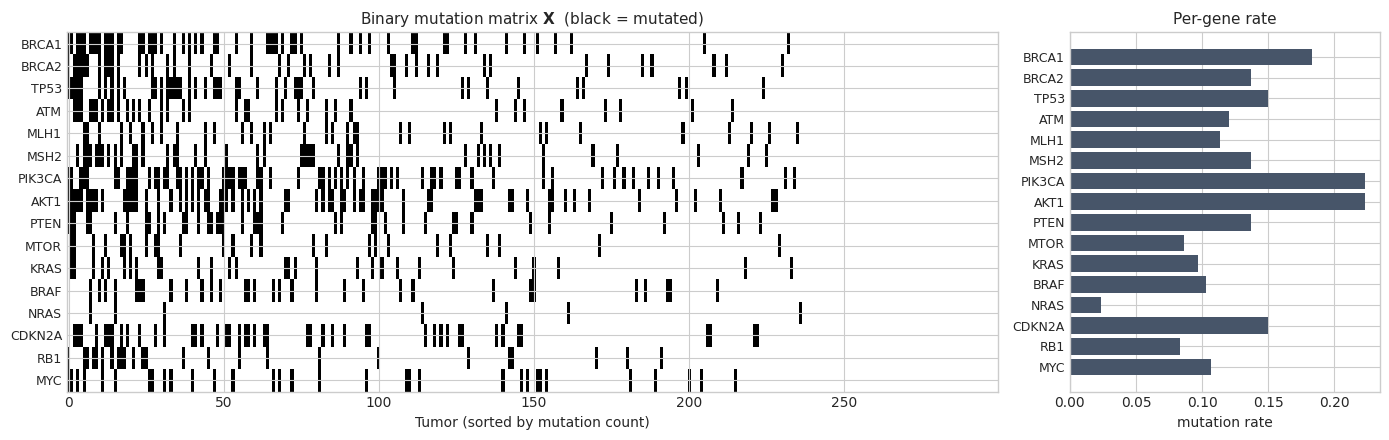

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5),
                         gridspec_kw={'width_ratios': [3, 1]})

# Mutation matrix (sorted by total mutation burden for readability)
order = np.argsort(-X.sum(1))
ax = axes[0]
ax.imshow(X[order].T, aspect='auto', cmap='Greys', interpolation='nearest')
ax.set_yticks(range(D))
ax.set_yticklabels(gene_names, fontsize=9)
ax.set_xlabel('Tumor (sorted by mutation count)')
ax.set_title('Binary mutation matrix $\\mathbf{X}$  '
             '(black = mutated)', fontsize=11)

# Per-gene mutation rate
ax = axes[1]
rates = X.mean(0)
y = np.arange(D)
ax.barh(y, rates, color='#475569')
ax.set_yticks(y)
ax.set_yticklabels(gene_names, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('mutation rate')
ax.set_title('Per-gene rate', fontsize=11)

plt.tight_layout()
plt.show()

## 2. Why Gaussian PCA Fails on Binary Data

Standard PCA / FA assume $x_{nd} \in \mathbb{R}$ with **Gaussian** noise around the linear reconstruction $\mathbf{W}\mathbf{z}_n$. For binary data this leads to two pathologies:

1. **Reconstructions can fall outside $[0, 1]$** — meaningless as probabilities.
2. **Wasted capacity modelling the bimodality** at $0$ and $1$. PCA tries to spread variance along directions that explain whether features are at $0$ or $1$, rather than the latent biological process.

Below we project the mutation matrix to $L = 2$ with PCA and look at the reconstructions $\hat{\mathbf{X}} = \mathbf{Z}\mathbf{W}^\top + \boldsymbol{\mu}$:

Reconstruction range: [-0.212, 1.369]   (should be in [0, 1] to be a probability)
Fraction of reconstructions outside [0, 1]: 13.98%


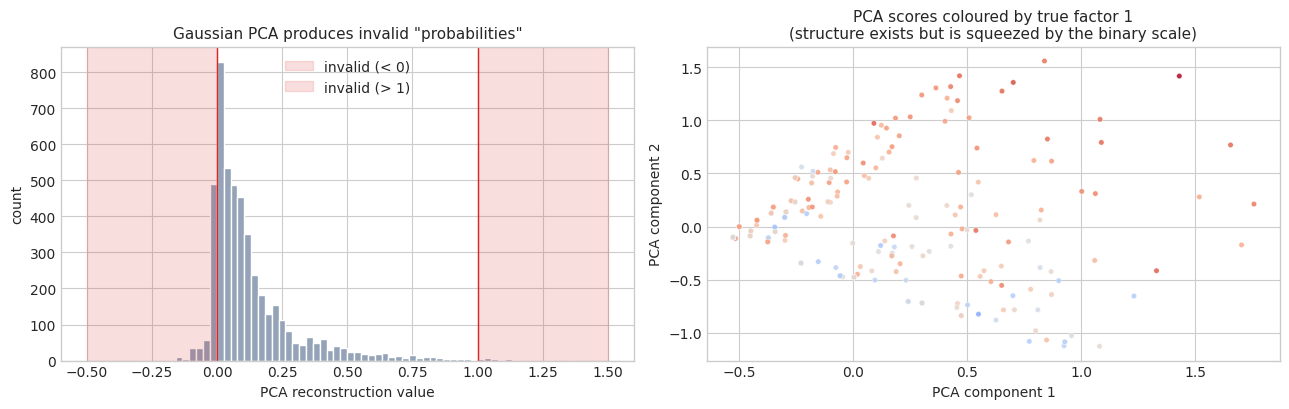

In [4]:
# Plain PCA on the binary matrix
mu_X = X.mean(0)
Xc = X - mu_X
U, s, Vt = np.linalg.svd(Xc, full_matrices=False)
L_fit = 2
Z_pca = U[:, :L_fit] * s[:L_fit]                # PCA scores
W_pca = Vt[:L_fit].T                             # PCA loadings
X_pca_hat = Z_pca @ W_pca.T + mu_X               # Reconstruction

print(f'Reconstruction range: '
      f'[{X_pca_hat.min():.3f}, {X_pca_hat.max():.3f}]   '
      f'(should be in [0, 1] to be a probability)')
print(f'Fraction of reconstructions outside [0, 1]: '
      f'{((X_pca_hat < 0) | (X_pca_hat > 1)).mean():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

ax = axes[0]
ax.hist(X_pca_hat.ravel(), bins=60, color='#94a3b8', edgecolor='white')
ax.axvspan(-0.5, 0, color='#dc2626', alpha=0.15, label='invalid (< 0)')
ax.axvspan(1, 1.5, color='#dc2626', alpha=0.15, label='invalid (> 1)')
ax.axvline(0, color='#dc2626', lw=1)
ax.axvline(1, color='#dc2626', lw=1)
ax.set_xlabel('PCA reconstruction value')
ax.set_ylabel('count')
ax.set_title('Gaussian PCA produces invalid "probabilities"', fontsize=11)
ax.legend()

ax = axes[1]
ax.scatter(Z_pca[:, 0], Z_pca[:, 1], c=Z_true[:, 0], cmap='coolwarm',
           s=15, alpha=0.85, edgecolor='white', linewidth=0.3)
ax.set_xlabel('PCA component 1')
ax.set_ylabel('PCA component 2')
ax.set_title('PCA scores coloured by true factor 1\n'
             '(structure exists but is squeezed by the binary scale)',
             fontsize=11)

plt.tight_layout()
plt.show()

## 3. Binary PCA: The Right Likelihood for Binary Data

The fix is to keep the **low-rank latent structure** $\mathbf{W}\mathbf{z}_n$ but pass it through the canonical link of the Bernoulli — the **sigmoid**:

$$p(\mathbf{x}_n \mid \mathbf{z}_n, \mathbf{W}, \mathbf{b}) = \prod_{d=1}^{D} \sigma(\eta_{nd})^{x_{nd}} \big(1 - \sigma(\eta_{nd})\big)^{1 - x_{nd}}, \qquad \eta_{nd} = \mathbf{w}_d^\top \mathbf{z}_n + b_d$$

with prior $p(\mathbf{z}_n) = \mathcal{N}(\mathbf{0}, \mathbf{I}_L)$. Reconstructions are now $\hat{p}_{nd} = \sigma(\eta_{nd}) \in (0, 1)$ — always valid probabilities.

### CDS02 coordinate-ascent objective

Replace the marginal likelihood with the **MAP objective** (treat $\mathbf{Z}$ as parameters with a Gaussian prior):

$$\mathcal{J}(\mathbf{Z}, \mathbf{W}, \mathbf{b}) = \sum_{n,d} \Big[x_{nd}\log \sigma(\eta_{nd}) + (1 - x_{nd})\log\!\big(1 - \sigma(\eta_{nd})\big)\Big] \;-\; \tfrac{1}{2}\sum_n \|\mathbf{z}_n\|^2$$

This is jointly concave in $\mathbf{W}$ (with $\mathbf{Z}$ fixed) and in $\mathbf{Z}$ (with $\mathbf{W}$ fixed) — both subproblems are L2-regularised logistic regressions. Note the prior on $\mathbf{Z}$ is essential: without it, scaling $\mathbf{Z} \to c\mathbf{Z}$, $\mathbf{W} \to c^{-1}\mathbf{W}$ leaves the likelihood unchanged, so the optimum is degenerate.

We implement it as joint L-BFGS on the flattened parameter vector — clean, fast, and avoids hand-coded coordinate updates.

In [5]:
def binary_pca_neg_log_post(params, X, L):
    """Negative MAP objective: -[log Bernoulli likelihood + log Gaussian prior on Z].

    Uses the numerically stable identity
        log sigmoid(eta) = -softplus(-eta),
        log(1 - sigmoid(eta)) = -softplus(eta),
    via numpy's logaddexp.
    """
    N, D = X.shape
    Z = params[:N * L].reshape(N, L)
    W = params[N * L:N * L + D * L].reshape(D, L)
    b = params[N * L + D * L:]

    eta = Z @ W.T + b                                  # (N, D)
    log_p1 = -np.logaddexp(0.0, -eta)                  # log sigmoid(eta)
    log_p0 = -np.logaddexp(0.0,  eta)                  # log(1 - sigmoid(eta))
    ll = np.sum(X * log_p1 + (1.0 - X) * log_p0)
    log_prior = -0.5 * np.sum(Z ** 2)

    neg_obj = -(ll + log_prior)

    # Gradient (same algebra as logistic regression)
    P = sigmoid(eta)
    R = X - P                                           # (N, D)
    gZ = -(R @ W) + Z                                   # neg-grad of log post wrt Z
    gW = -(R.T @ Z)
    gb = -R.sum(0)
    grad = np.concatenate([gZ.ravel(), gW.ravel(), gb])
    return neg_obj, grad


def fit_binary_pca(X, L, n_restarts=3, seed=0):
    """Fit binary PCA via L-BFGS on the joint MAP objective. Take the best of
    several random restarts because the surface, while concave per-block, is
    non-convex jointly.
    """
    N, D = X.shape
    best = None
    rng_local = np.random.default_rng(seed)
    for r in range(n_restarts):
        x0 = 0.1 * rng_local.standard_normal(N * L + D * L + D)
        res = minimize(
            binary_pca_neg_log_post,
            x0=x0, args=(X, L), jac=True, method='L-BFGS-B',
            options={'maxiter': 500, 'gtol': 1e-6, 'disp': False},
        )
        if best is None or res.fun < best.fun:
            best = res
    Z = best.x[:N * L].reshape(N, L)
    W = best.x[N * L:N * L + D * L].reshape(D, L)
    b = best.x[N * L + D * L:]
    return Z, W, b, -best.fun


Z_bpca, W_bpca, b_bpca, log_post = fit_binary_pca(X, L=L_true, n_restarts=4)
P_hat = sigmoid(Z_bpca @ W_bpca.T + b_bpca)

print(f'Optimisation converged.  log posterior = {log_post:.2f}')
print(f'Reconstruction range: [{P_hat.min():.3f}, {P_hat.max():.3f}]   '
      f'(always in [0, 1] thanks to sigmoid)')

Optimisation converged.  log posterior = -1079.58
Reconstruction range: [0.000, 1.000]   (always in [0, 1] thanks to sigmoid)


## 4. Comparing Reconstructions: Gaussian PCA vs Binary PCA

Two metrics, both honest:

- **Bernoulli log-likelihood** of the held-out data under each reconstruction (using PCA reconstructions clipped to $[\epsilon, 1 - \epsilon]$ for fairness).
- **Per-gene calibration**: how close the reconstruction average matches the empirical mutation rate.

In [6]:
# Train/test split
perm = rng.permutation(N)
tr, te = perm[:240], perm[240:]

# --- PCA refit on train, project test ---
mu_tr = X[tr].mean(0)
U_, s_, Vt_ = np.linalg.svd(X[tr] - mu_tr, full_matrices=False)
W_pca_tr = Vt_[:L_true].T
Z_te_pca = (X[te] - mu_tr) @ W_pca_tr
X_pca_hat_te = np.clip(Z_te_pca @ W_pca_tr.T + mu_tr, 1e-3, 1 - 1e-3)

# --- Binary PCA: refit W, b on train, infer test latents holding W fixed ---
Z_tr_bpca, W_tr, b_tr, _ = fit_binary_pca(X[tr], L=L_true, n_restarts=4, seed=1)

def infer_z(X_new, W, b):
    """Per-row L-BFGS to infer z_n given fixed (W, b). L2-regularised logistic regression."""
    L = W.shape[1]
    Z = np.zeros((X_new.shape[0], L))
    for n in range(X_new.shape[0]):
        x = X_new[n]
        def obj(z):
            eta = W @ z + b
            log_p1 = -np.logaddexp(0.0, -eta)
            log_p0 = -np.logaddexp(0.0,  eta)
            ll = np.sum(x * log_p1 + (1 - x) * log_p0)
            P = sigmoid(eta)
            grad_z = -W.T @ (x - P) + z
            return -(ll - 0.5 * z @ z), grad_z
        Z[n] = minimize(obj, x0=np.zeros(L), jac=True, method='L-BFGS-B').x
    return Z

Z_te_bpca = infer_z(X[te], W_tr, b_tr)
X_bpca_hat_te = sigmoid(Z_te_bpca @ W_tr.T + b_tr)

def bernoulli_ll(X_true, P):
    P = np.clip(P, 1e-6, 1 - 1e-6)
    return (X_true * np.log(P) + (1 - X_true) * np.log(1 - P)).mean()

ll_pca = bernoulli_ll(X[te], X_pca_hat_te)
ll_bpca = bernoulli_ll(X[te], X_bpca_hat_te)
ll_base = bernoulli_ll(X[te], np.tile(X[tr].mean(0), (len(te), 1)))

print('Held-out Bernoulli log-likelihood per (tumor, gene) cell:')
print(f'  Marginal baseline (per-gene rate): {ll_base:8.4f}')
print(f'  Gaussian PCA (clipped):            {ll_pca:8.4f}')
print(f'  Binary PCA:                        {ll_bpca:8.4f}     (\u0394 vs PCA = {ll_bpca - ll_pca:+.4f})')

Held-out Bernoulli log-likelihood per (tumor, gene) cell:
  Marginal baseline (per-gene rate):  -0.3538
  Gaussian PCA (clipped):             -0.2336
  Binary PCA:                         -0.1914     (Δ vs PCA = +0.0422)


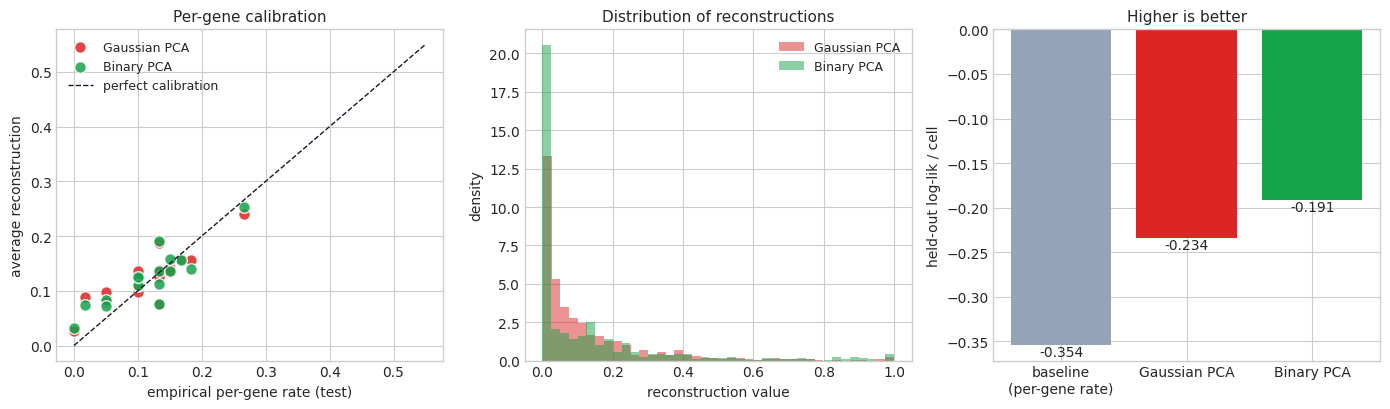

In [7]:
# Visualise reconstruction quality
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

# Calibration: reconstructed prob vs empirical rate, per gene
ax = axes[0]
ax.scatter(X[te].mean(0), X_pca_hat_te.mean(0), s=70, color='#dc2626',
           label='Gaussian PCA', alpha=0.85, edgecolor='white')
ax.scatter(X[te].mean(0), X_bpca_hat_te.mean(0), s=70, color='#16a34a',
           label='Binary PCA', alpha=0.85, edgecolor='white')
lims = [0, max(X[te].mean(0).max(), 0.5) + 0.05]
ax.plot(lims, lims, '--', color='#111827', lw=1, label='perfect calibration')
ax.set_xlabel('empirical per-gene rate (test)')
ax.set_ylabel('average reconstruction')
ax.set_title('Per-gene calibration', fontsize=11)
ax.legend(fontsize=9)

# Histogram of reconstruction values
ax = axes[1]
ax.hist(X_pca_hat_te.ravel(), bins=40, color='#dc2626', alpha=0.5,
        label='Gaussian PCA', density=True)
ax.hist(X_bpca_hat_te.ravel(), bins=40, color='#16a34a', alpha=0.5,
        label='Binary PCA', density=True)
ax.set_xlabel('reconstruction value')
ax.set_ylabel('density')
ax.set_title('Distribution of reconstructions', fontsize=11)
ax.legend(fontsize=9)

# Bernoulli log-likelihood bar chart
ax = axes[2]
names = ['baseline\n(per-gene rate)', 'Gaussian PCA', 'Binary PCA']
vals = [ll_base, ll_pca, ll_bpca]
colors = ['#94a3b8', '#dc2626', '#16a34a']
bars = ax.bar(names, vals, color=colors)
ax.set_ylabel('held-out log-lik / cell')
ax.set_title('Higher is better', fontsize=11)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v, f'{v:.3f}',
            ha='center', va='bottom' if v >= 0 else 'top', fontsize=10)

plt.tight_layout()
plt.show()

## 5. The Latent Pathway Space

Binary PCA produces a continuous low-dimensional embedding $\hat{\mathbf{Z}}$ on which we can:

- **Visualise tumor heterogeneity** — does the embedding recover the latent biology used to simulate the data?
- **Read off pathway loadings** — does each column of $\hat{\mathbf{W}}$ map onto a meaningful gene set?

Like Gaussian factor analysis (§20.2.4), binary PCA is **rotation-invariant** in the latent space — replacing $(\mathbf{Z}, \mathbf{W})$ with $(\mathbf{Z}\mathbf{R}, \mathbf{W}\mathbf{R})$ for any orthogonal $\mathbf{R}$ gives the same likelihood. We use Procrustes alignment to compare to the simulation truth.

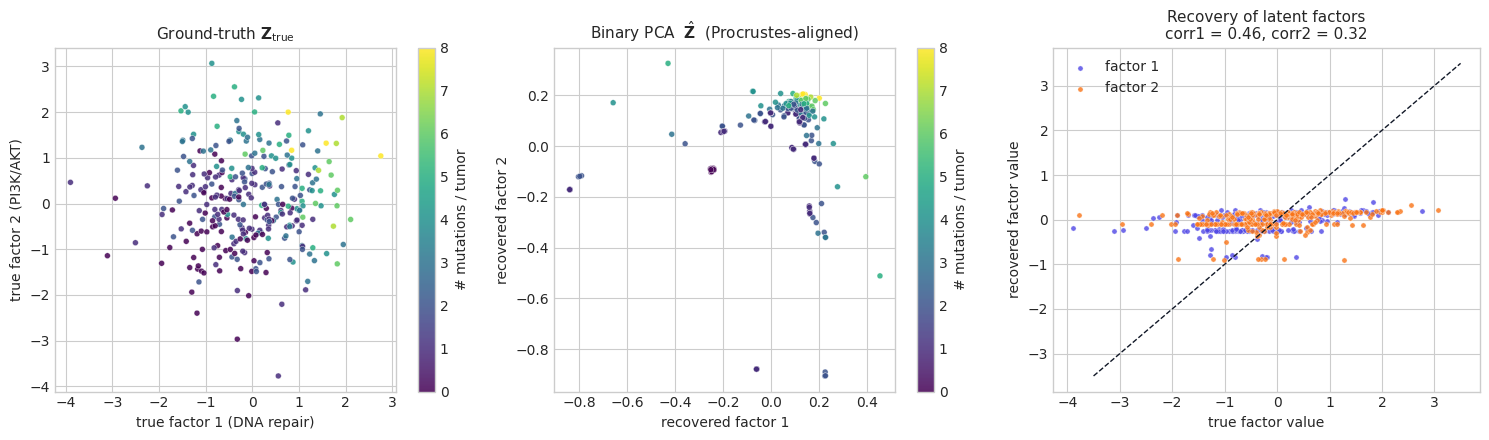

In [8]:
# Procrustes-align the recovered Z to the simulation truth
U_p, _, Vt_p = np.linalg.svd(Z_bpca.T @ Z_true)
R_align = U_p @ Vt_p
Z_aligned = Z_bpca @ R_align
W_aligned = W_bpca @ R_align

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) True latent space
ax = axes[0]
sc = ax.scatter(Z_true[:, 0], Z_true[:, 1], c=X.sum(1), cmap='viridis',
                s=18, alpha=0.85, edgecolor='white', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='# mutations / tumor')
ax.set_xlabel('true factor 1 (DNA repair)')
ax.set_ylabel('true factor 2 (PI3K/AKT)')
ax.set_title('Ground-truth $\\mathbf{Z}_{\\rm true}$', fontsize=11)

# (b) Recovered latent space
ax = axes[1]
sc = ax.scatter(Z_aligned[:, 0], Z_aligned[:, 1], c=X.sum(1), cmap='viridis',
                s=18, alpha=0.85, edgecolor='white', linewidth=0.3)
plt.colorbar(sc, ax=ax, label='# mutations / tumor')
ax.set_xlabel('recovered factor 1')
ax.set_ylabel('recovered factor 2')
ax.set_title('Binary PCA  $\\hat{\\mathbf{Z}}$  '
             '(Procrustes-aligned)', fontsize=11)

# (c) Per-tumor: scatter of recovered vs true factor 1
ax = axes[2]
ax.scatter(Z_true[:, 0], Z_aligned[:, 0], color='#4f46e5', s=14, alpha=0.8,
           edgecolor='white', linewidth=0.3, label='factor 1')
ax.scatter(Z_true[:, 1], Z_aligned[:, 1], color='#f97316', s=14, alpha=0.8,
           edgecolor='white', linewidth=0.3, label='factor 2')
lims = [-3.5, 3.5]
ax.plot(lims, lims, '--', color='#111827', lw=1)
ax.set_xlabel('true factor value')
ax.set_ylabel('recovered factor value')
ax.set_title(f'Recovery of latent factors\n'
             f'corr1 = {np.corrcoef(Z_true[:, 0], Z_aligned[:, 0])[0, 1]:.2f}, '
             f'corr2 = {np.corrcoef(Z_true[:, 1], Z_aligned[:, 1])[0, 1]:.2f}',
             fontsize=11)
ax.legend()

plt.tight_layout()
plt.show()

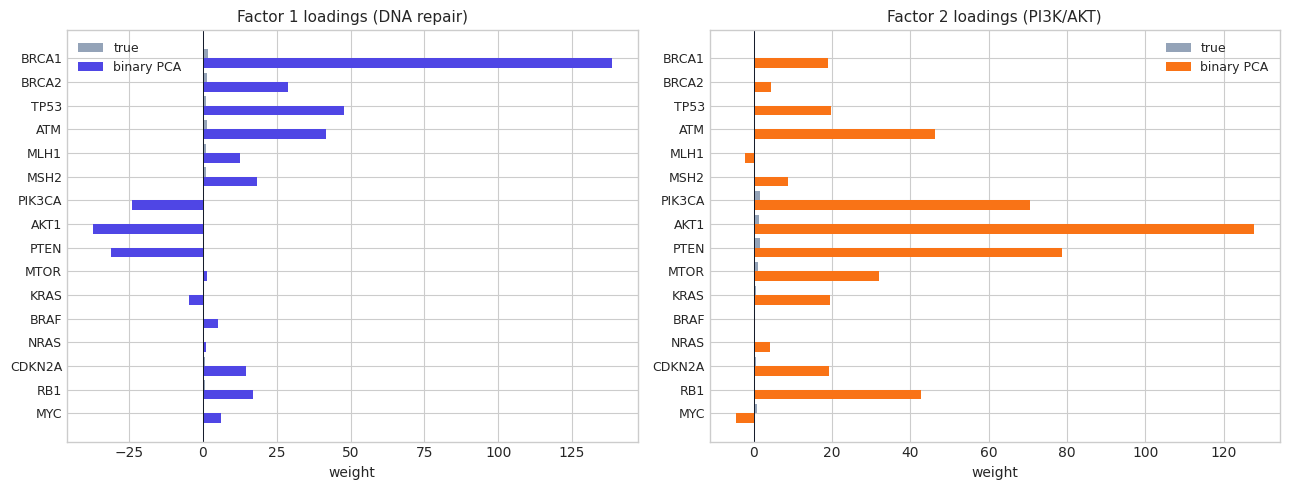

Correlation of recovered vs true loadings:
  Factor 1: 0.821
  Factor 2: 0.712


In [9]:
# Compare loadings: does W_bpca align with W_true once we remove rotational ambiguity?
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

y = np.arange(D)
ax = axes[0]
ax.barh(y - 0.2, W_true[:, 0],   height=0.4, color='#94a3b8', label='true')
ax.barh(y + 0.2, W_aligned[:, 0], height=0.4, color='#4f46e5',
        label='binary PCA')
ax.set_yticks(y); ax.set_yticklabels(gene_names, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='#111827', lw=0.7)
ax.set_title('Factor 1 loadings (DNA repair)', fontsize=11)
ax.set_xlabel('weight')
ax.legend(fontsize=9)

ax = axes[1]
ax.barh(y - 0.2, W_true[:, 1],   height=0.4, color='#94a3b8', label='true')
ax.barh(y + 0.2, W_aligned[:, 1], height=0.4, color='#f97316',
        label='binary PCA')
ax.set_yticks(y); ax.set_yticklabels(gene_names, fontsize=9)
ax.invert_yaxis()
ax.axvline(0, color='#111827', lw=0.7)
ax.set_title('Factor 2 loadings (PI3K/AKT)', fontsize=11)
ax.set_xlabel('weight')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Correlation of recovered vs true loadings:')
print(f'  Factor 1: {np.corrcoef(W_true[:, 0], W_aligned[:, 0])[0, 1]:.3f}')
print(f'  Factor 2: {np.corrcoef(W_true[:, 1], W_aligned[:, 1])[0, 1]:.3f}')

## 6. Categorical PCA: Genotypes Beyond Binary

If observations are categorical with $K$ levels (e.g. SNP **genotypes** $\{\text{AA}, \text{Aa}, \text{aa}\}$, or staining intensity coded $\{0, 1, 2, 3\}$), Eq. 20.76 generalises binary PCA via softmax:

$$p(x_{nd} = k \mid \mathbf{z}_n) = \frac{\exp\!\big(\mathbf{w}_{dk}^\top \mathbf{z}_n + b_{dk}\big)}{\sum_{k'=1}^{K}\exp\!\big(\mathbf{w}_{dk'}^\top \mathbf{z}_n + b_{dk'}\big)}$$

Each feature $d$ now has $K$ weight vectors $\{\mathbf{w}_{dk}\}_{k=1}^K$ instead of one. Identifiability requires fixing one class per feature as a reference (we set $\mathbf{w}_{d0} = \mathbf{0}$, $b_{d0} = 0$).

We simulate $D = 10$ SNP loci across $N = 250$ patients, generated from $L = 2$ ancestry-like factors, and recover the embedding.

In [10]:
# Simulate categorical (3-level) data
K_cat = 3      # genotype categories: AA / Aa / aa
D_cat = 10
L_cat = 2
N_cat = 250

rng_c = np.random.default_rng(42)
Z_true_c = rng_c.standard_normal((N_cat, L_cat))
# True per-feature weights for classes 1 and 2 (class 0 is reference)
W_true_c = rng_c.standard_normal((D_cat, K_cat - 1, L_cat)) * 1.2
b_true_c = rng_c.standard_normal((D_cat, K_cat - 1)) * 0.5

def softmax_with_ref(eta_minus0):
    """Softmax over [0, eta_1, ..., eta_{K-1}] (class 0 is the reference)."""
    eta_full = np.concatenate([np.zeros(eta_minus0.shape[:-1] + (1,)), eta_minus0],
                              axis=-1)
    return np.exp(eta_full - logsumexp(eta_full, axis=-1, keepdims=True))

# (N, D, K-1) logits
eta_true_c = np.einsum('nl,dkl->ndk', Z_true_c, W_true_c) + b_true_c
P_cat = softmax_with_ref(eta_true_c)                 # (N, D, K)
# Sample one category per (n, d)
X_cat = np.zeros((N_cat, D_cat), dtype=int)
for n in range(N_cat):
    for d in range(D_cat):
        X_cat[n, d] = rng_c.choice(K_cat, p=P_cat[n, d])

print(f'Genotype counts per category:  '
      f'AA={int((X_cat == 0).sum())}, '
      f'Aa={int((X_cat == 1).sum())}, '
      f'aa={int((X_cat == 2).sum())}')

Genotype counts per category:  AA=728, Aa=828, aa=944


In [11]:
def cat_pca_neg_log_post(params, X_int, K, L):
    """Negative MAP objective for categorical PCA. Reference class = 0.

    Parameter layout: [Z (N*L), W (D*(K-1)*L), b (D*(K-1))].
    """
    N, D = X_int.shape
    nZ = N * L
    nW = D * (K - 1) * L
    Z = params[:nZ].reshape(N, L)
    W = params[nZ:nZ + nW].reshape(D, K - 1, L)
    b = params[nZ + nW:].reshape(D, K - 1)

    eta = np.einsum('nl,dkl->ndk', Z, W) + b           # (N, D, K-1)
    eta_full = np.concatenate([np.zeros((N, D, 1)), eta], axis=-1)
    log_Z = logsumexp(eta_full, axis=-1)               # (N, D)
    # log p(x_nd) = eta_full[n, d, x_nd] - log_Z[n, d]
    pick = np.take_along_axis(eta_full, X_int[..., None], axis=-1).squeeze(-1)
    ll = (pick - log_Z).sum()
    log_prior = -0.5 * np.sum(Z ** 2)

    P_full = np.exp(eta_full - log_Z[..., None])       # (N, D, K)
    onehot = np.zeros_like(P_full)
    np.put_along_axis(onehot, X_int[..., None], 1.0, axis=-1)
    R = onehot - P_full                                 # gradient signal, (N, D, K)
    R_minus0 = R[..., 1:]                               # drop reference class

    gZ = -np.einsum('ndk,dkl->nl', R_minus0, W) + Z
    gW = -np.einsum('ndk,nl->dkl', R_minus0, Z)
    gb = -R_minus0.sum(0)
    grad = np.concatenate([gZ.ravel(), gW.ravel(), gb.ravel()])
    return -(ll + log_prior), grad


def fit_cat_pca(X_int, K, L, n_restarts=4, seed=0):
    N, D = X_int.shape
    n_params = N * L + D * (K - 1) * L + D * (K - 1)
    rng_local = np.random.default_rng(seed)
    best = None
    for r in range(n_restarts):
        x0 = 0.1 * rng_local.standard_normal(n_params)
        res = minimize(cat_pca_neg_log_post, x0=x0, args=(X_int, K, L),
                       jac=True, method='L-BFGS-B',
                       options={'maxiter': 500, 'gtol': 1e-6})
        if best is None or res.fun < best.fun:
            best = res
    nZ = N * L
    nW = D * (K - 1) * L
    Z = best.x[:nZ].reshape(N, L)
    W = best.x[nZ:nZ + nW].reshape(D, K - 1, L)
    b = best.x[nZ + nW:].reshape(D, K - 1)
    return Z, W, b, -best.fun


Z_cpca, W_cpca, b_cpca, _ = fit_cat_pca(X_cat, K=K_cat, L=L_cat, n_restarts=4)

# Procrustes-align recovered Z to truth
U_p, _, Vt_p = np.linalg.svd(Z_cpca.T @ Z_true_c)
R_c = U_p @ Vt_p
Z_cpca_aligned = Z_cpca @ R_c

# Predicted class probabilities
eta_hat = np.einsum('nl,dkl->ndk', Z_cpca, W_cpca) + b_cpca
P_cat_hat = softmax_with_ref(eta_hat)
predicted = P_cat_hat.argmax(-1)
acc = (predicted == X_cat).mean()
marginal_acc = max((X_cat == 0).mean(), (X_cat == 1).mean(), (X_cat == 2).mean())
print(f'CatPCA reconstruction accuracy:        {acc:.3f}')
print(f'Most-frequent-class baseline accuracy: {marginal_acc:.3f}')

CatPCA reconstruction accuracy:        0.706
Most-frequent-class baseline accuracy: 0.378


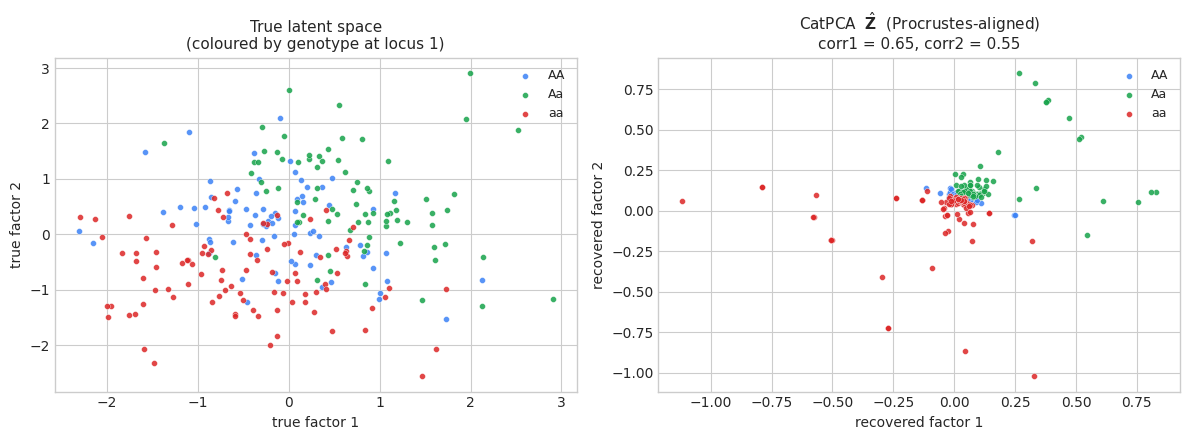

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# True latent space coloured by genotype at locus 0
ax = axes[0]
for k, (lab, c) in enumerate(zip(['AA', 'Aa', 'aa'],
                                 ['#3b82f6', '#16a34a', '#dc2626'])):
    mask = X_cat[:, 0] == k
    ax.scatter(Z_true_c[mask, 0], Z_true_c[mask, 1], s=18, color=c,
               alpha=0.85, edgecolor='white', linewidth=0.3, label=lab)
ax.set_xlabel('true factor 1'); ax.set_ylabel('true factor 2')
ax.set_title('True latent space\n(coloured by genotype at locus 1)', fontsize=11)
ax.legend(fontsize=9)

# Recovered latent space
ax = axes[1]
for k, (lab, c) in enumerate(zip(['AA', 'Aa', 'aa'],
                                 ['#3b82f6', '#16a34a', '#dc2626'])):
    mask = X_cat[:, 0] == k
    ax.scatter(Z_cpca_aligned[mask, 0], Z_cpca_aligned[mask, 1], s=18, color=c,
               alpha=0.85, edgecolor='white', linewidth=0.3, label=lab)
ax.set_xlabel('recovered factor 1'); ax.set_ylabel('recovered factor 2')
ax.set_title('CatPCA  $\\hat{\\mathbf{Z}}$  (Procrustes-aligned)\n'
             f'corr1 = {np.corrcoef(Z_true_c[:, 0], Z_cpca_aligned[:, 0])[0, 1]:.2f}, '
             f'corr2 = {np.corrcoef(Z_true_c[:, 1], Z_cpca_aligned[:, 1])[0, 1]:.2f}',
             fontsize=11)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## Summary

- **Exponential family FA** (Eq. 20.73) keeps the low-rank structure $\boldsymbol{\Theta} = \mathbf{Z}\mathbf{W}^\top$ of FA / PPCA but lets the natural parameters drive *any* exponential family — Bernoulli, Categorical, Poisson, etc. — appropriate to the data.
- **Binary PCA** (§20.2.7.1) is the Bernoulli special case. The natural parameters are passed through the sigmoid: $p(x_{nd} = 1) = \sigma(\mathbf{w}_d^\top \mathbf{z}_n + b_d)$. This yields valid probabilities in $(0, 1)$ and a held-out log-likelihood much higher than Gaussian PCA, which produces nonsensical reconstructions outside $[0, 1]$.
- **Categorical PCA / CatPCA** (§20.2.7.2) is the multinomial special case via softmax — the natural extension to genotypes, ordinal scales, or any discrete observations with $K > 2$ classes.
- **Loss of conjugacy.** The Gaussian prior on $\mathbf{z}_n$ is no longer conjugate to the Bernoulli/Categorical likelihood, so we cannot integrate $\mathbf{z}_n$ out in closed form. Two practical fits:
  - **CDS02 coordinate ascent** (used here) — alternate L2-regularised logistic / softmax regression for $\mathbf{Z}$ and for $\mathbf{W}$. Equivalent to variational EM with a $\delta$-function posterior. Watch out: with $\mathbf{Z}$ as parameters the latent dimension grows with $N$, so a non-degenerate posterior is preferred for very small $N$.
  - **Variational EM** with a Gaussian $q(\mathbf{z}_n) = \mathcal{N}(\mathbf{m}_n, \mathbf{S}_n)$ — Tipping (1998) for binary, Khan et al. (2010) for categorical.
- **Rotational unidentifiability** carries over from §20.2.4: the Gaussian prior on $\mathbf{z}_n$ is rotation-invariant, so $(\mathbf{Z}, \mathbf{W})$ and $(\mathbf{Z}\mathbf{R}, \mathbf{W}\mathbf{R})$ have the same likelihood for any orthogonal $\mathbf{R}$. We recover the latent *subspace*, not the named axes.
- **The pipeline ahead.** Exponential family FA is the linear conceptual stepping stone to **deep latent-variable models** for non-Gaussian data: replace $\mathbf{w}_d^\top \mathbf{z}_n$ with a neural-network $f_d(\mathbf{z}_n; \boldsymbol{\theta})$ and you have a discrete-output VAE (§20.3.5).